# 06 — Models, validation and metrics

**Rahnema College ML Bootcamp 1405** · Week 3, after lunch · Peyman Naseri

---

This morning we built the left half of the pipeline: preprocessing and
features. This afternoon is the right half — fitting something, measuring it
honestly, and knowing what the measurement leaves out.

Back to the small delivery dataset, because the ideas are easier to see when
everything runs in a second. Notebook 07 puts all of it back on the real
forecasting problem.

## The order of this notebook

1. **Fit a model.** It takes three lines, and it is the least interesting part.
2. **Four ways the score lies to you.** This is the long section, and it is the
   one worth your attention.
3. **Which cross-validation scheme**, and how to choose.
4. **Metrics**, and what each of them hides.
5. **Error analysis** — saying what the model is bad at before anyone asks.

## On the four leaks

Every one is a real mistake. I have made two of them myself and one of them
shipped. The format: I show the code, you get a minute with the person next to
you to guess what is wrong, then we run it and watch the number move. Guess
before I run it — the guessing is the part that sticks.

| # | The leak | What it looks like |
|---|---|---|
| 1 | columns from the future | a feature that did not exist yet |
| 2 | group leakage | the same courier on both sides of the split |
| 3 | time leakage | shuffling rows that have an order |
| 4 | target encoding | the answer, folded back into a feature |

The fourth is the worst, because it survives every review that does not
specifically look for it.

---

## 1. Fitting a model is the easy part

Three lines, using the same estimator interface as every transformer from this
morning. `HistGradientBoostingRegressor` is the sensible default for tabular
data: fast, handles non-linearity and interactions on its own, needs almost no
tuning to be respectable. Start here and only reach for something else once you
have a reason.

Before it, though, a **baseline**. Until you have a number to beat you cannot
tell whether your model is good — only that it runs. The baseline should be
something the business could do without you.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.metrics import mean_absolute_error

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
import sys
sys.path.insert(0, str(ROOT))
from bootcamp import cv_schemes, metrics_sheet

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", rc=plt.rcParams)

RANDOM_STATE = 3

# Same load and same time features as notebook 04, so every number below is
# comparable with the one we finished on before lunch.
deliveries = (pd.read_csv(DATA / "deliveries.csv", parse_dates=["order_time"])
              .assign(hour=lambda d: d["order_time"].dt.hour,
                      weekday=lambda d: d["order_time"].dt.dayofweek,
                      is_evening=lambda d: (d["order_time"].dt.hour >= 19).astype(int)))

NUMERIC = ["distance_km", "prep_minutes", "basket_size", "basket_value_toman",
           "hour", "weekday", "is_evening"]
CATEGORICAL = ["store", "courier_type", "weather"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "delivery_minutes"

y = deliveries[TARGET]
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"{len(deliveries):,} orders loaded")

12,000 orders loaded


Everything below compares against the number from before lunch, so we need the
same pipeline again — this time as a function, because we are about to build a
dozen variations of it.

Notice that `make_pipeline_for` takes the column lists as arguments. Hard-coding
them would mean copy-pasting the whole pipeline for every experiment, and by
the third copy the versions would have drifted apart.

In [2]:
def make_pipeline_for(numeric, categorical, extra_steps=None):
    """The before-lunch pipeline, parameterised by which columns go where."""
    branches = [
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]), categorical),
    ]
    # extra_steps lets a caller bolt on another branch -- we use it later to
    # drop a TargetEncoder in beside the other two without duplicating any of
    # this.
    branches += extra_steps or []
    return Pipeline([
        ("prep", ColumnTransformer(branches)),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ])


def cv_mae(pipe, X, target, cv=cv5, groups=None):
    """Cross-validated MAE, positive and in minutes."""
    scores = cross_val_score(pipe, X, target, cv=cv, groups=groups,
                             scoring="neg_mean_absolute_error")
    return -scores.mean()


from sklearn.dummy import DummyRegressor

# The baseline: predict the median, always. Something the business could do
# without us, and the number every later model has to beat.
baseline_mae = -cross_val_score(DummyRegressor(strategy="median"),
                                deliveries[FEATURES], y, cv=cv5,
                                scoring="neg_mean_absolute_error").mean()

# The model. Same .fit interface as every transformer this morning.
honest_mae = cv_mae(make_pipeline_for(NUMERIC, CATEGORICAL), deliveries[FEATURES], y)

print(f"baseline (predict the median): {baseline_mae:.2f} min")
print(f"pipeline + gradient boosting : {honest_mae:.2f} min"
      f"   ({(1 - honest_mae / baseline_mae) * 100:.0f}% better)")
print("\nThat second number is the one the rest of this notebook attacks.")

baseline (predict the median): 6.73 min
pipeline + gradient boosting : 4.90 min   (27% better)

That second number is the one the rest of this notebook attacks.


---

# Leak 1 — columns that did not exist yet

Before lunch we set aside `actual_route_km`, `rating` and `tip_toman` because
none of them exist when the order is placed.

We never measured what taking them would have done. Let's find out, because the
size of the number is the argument.

In [3]:
# One row per experiment: add a single forbidden column, refit, re-score.
# Adding them one at a time is the point -- the sizes are very different.
rows = [{"features": "honest (before lunch)", "cv_mae": honest_mae}]

for leak in ["actual_route_km", "rating", "tip_toman"]:
    mae = cv_mae(make_pipeline_for(NUMERIC + [leak], CATEGORICAL),
                 deliveries[FEATURES + [leak]], y)
    rows.append({"features": f"+ {leak}", "cv_mae": mae})

all_three = ["actual_route_km", "rating", "tip_toman"]
rows.append({"features": "+ all three", 
             "cv_mae": cv_mae(make_pipeline_for(NUMERIC + all_three, CATEGORICAL),
                              deliveries[FEATURES + all_three], y)})

leak1 = pd.DataFrame(rows)
leak1["vs honest"] = (1 - leak1["cv_mae"] / honest_mae).map("{:+.0%}".format)
print(leak1.round(2).to_string(index=False))

             features  cv_mae vs honest
honest (before lunch)    4.90       +0%
    + actual_route_km    4.04      +18%
             + rating    3.65      +26%
          + tip_toman    4.89       +0%
          + all three    3.28      +33%


Read the `tip_toman` row carefully, because it is the point of the whole table.

**`rating` and `actual_route_km` make the model look dramatically better.** Of
course they do — one is a customer reacting to how long they waited, the other
is the distance the courier actually rode. Both are half the answer. A model
built on them would score beautifully in your notebook and then predict nothing
useful in production, because at prediction time those columns are empty.

**`tip_toman` changes nothing at all.** It is just as illegal as the other two,
and the score cannot tell you that.

That asymmetry is the lesson:

> **"Does it improve the score" is not the test for whether a column is
> allowed. "Was it available at prediction time" is.**

If you use the score as your filter, you will keep every leak that helps and
happily keep the useless illegal columns too. The only reliable filter is going
down the column list and asking, one at a time, when each value gets written.

**How to actually do this at work:** ask the engineer who owns the table when
each column is populated. Not what it means — *when it is written*. It takes
twenty minutes and it is the highest-value twenty minutes of the project.

---

# Leak 2 — the same courier on both sides

`courier_id` passes the availability test: dispatch assigns the courier when
the order is placed, so we genuinely know it.

It is also a legitimately useful feature. Couriers differ — some are simply
faster than others, consistently, and the model can learn that.

So we add it. What could go wrong?

In [4]:
# Before using an id as a feature, look at how often each value repeats.
# That number is what decides whether group leakage is a risk at all.
vc = deliveries["courier_id"].value_counts()
print(f"{deliveries['courier_id'].nunique()} couriers over {len(deliveries):,} orders")
print(f"orders per courier: median {vc.median():.0f}, max {vc.max()}, min {vc.min()}")

CAT_WITH_COURIER = CATEGORICAL + ["courier_id"]
X_courier = deliveries[FEATURES + ["courier_id"]]

random_fold = cv_mae(make_pipeline_for(NUMERIC, CAT_WITH_COURIER), X_courier, y)
print(f"\nwith courier_id, ordinary 5-fold CV: {random_fold:.2f} min"
      f"   ({(1 - random_fold / honest_mae):+.0%} vs honest)")

200 couriers over 12,000 orders
orders per courier: median 43, max 317, min 1



with courier_id, ordinary 5-fold CV: 4.23 min   (+14% vs honest)


A solid improvement. Ship it?

No — think about what the folds look like. The busiest couriers have hundreds
of orders each. Shuffle the rows into five folds and **every one of those
couriers appears in the training fold and the validation fold at the same
time.** The model does not need to learn anything about deliveries; it can
memorise "C0043 takes about 17 minutes" and read the answer back.

That works right up until a courier the model has never seen takes an order.

`GroupKFold` fixes the measurement: it keeps all of a courier's rows on one
side of the split, so the validation fold only ever contains couriers the model
did not train on.

In [5]:
from sklearn.model_selection import GroupKFold

# Same pipeline, same features, same data. The only change is `groups`,
# which tells the splitter to keep every row of a courier on one side.
grouped = cv_mae(make_pipeline_for(NUMERIC, CAT_WITH_COURIER), X_courier, y,
                 cv=GroupKFold(n_splits=5), groups=deliveries["courier_id"])

print(f"random KFold : {random_fold:.2f} min   <- the flattering number")
print(f"GroupKFold   : {grouped:.2f} min   <- what a new courier actually gets")
print(f"honest, no courier_id at all: {honest_mae:.2f} min")
print(f"\nthe gap the shuffle was hiding: {grouped - random_fold:+.2f} min")

random KFold : 4.23 min   <- the flattering number
GroupKFold   : 4.86 min   <- what a new courier actually gets
honest, no courier_id at all: 4.90 min

the gap the shuffle was hiding: +0.64 min


So `courier_id` is worth far less than the shuffled folds claimed, and roughly
nothing once you measure it honestly.

**Which number is right depends on a question about the world, not about
statistics:** will the couriers you predict for tomorrow be the couriers you
trained on?

- A stable fleet where the same 200 people ride every day → the random-fold
  number is closer to the truth, and `courier_id` is a fine feature.
- High turnover, new riders every week → `GroupKFold` is the honest estimate,
  and the feature is close to worthless.

You cannot answer that from the dataframe. You have to ask the operations team.

**Where this bites in other domains — the pattern is always "repeated units":**

| Domain | The group |
|---|---|
| medical imaging | the patient, not the scan |
| credit risk | the customer, not the loan |
| speech | the speaker, not the utterance |
| manufacturing | the machine, not the part |
| this notebook | the courier, not the delivery |

Any time one real-world entity produces many rows, ask whether it can appear on
both sides of your split.

---

# Leak 3 — the shuffle that lets you see the future

Now the split we made before lunch, which I asked you to hold on to.

We know the target drifts: deliveries got faster over the period. And we
shuffled the rows anyway, which means each validation fold is surrounded — on
both sides, in time — by training data.

A model validated that way is being asked to *interpolate between* days it has
already seen. A model in production is being asked to *extrapolate past* every
day it has seen. Those are different problems, and only one of them is yours.

In [6]:
ordered = deliveries.sort_values("order_time").reset_index(drop=True)
y_ordered = ordered[TARGET]
pipe = make_pipeline_for(NUMERIC, CATEGORICAL)

from sklearn.model_selection import TimeSeriesSplit

shuffled = cv_mae(pipe, ordered[FEATURES], y_ordered, cv=cv5)
forward = cv_mae(pipe, ordered[FEATURES], y_ordered, cv=TimeSeriesSplit(n_splits=5))

# The strictest test we can run: train on the first 80% of history, predict
# the last 20%. This is the closest thing to "deploy it and wait".
cut = int(len(ordered) * 0.8)
past, future = ordered.iloc[:cut], ordered.iloc[cut:]
fitted = pipe.fit(past[FEATURES], past[TARGET])
future_mae = mean_absolute_error(future[TARGET], fitted.predict(future[FEATURES]))

print(f"shuffled 5-fold CV        : {shuffled:.2f} min")
print(f"TimeSeriesSplit           : {forward:.2f} min   ({(forward/shuffled-1):+.0%})")
print(f"train on past, score future: {future_mae:.2f} min   ({(future_mae/shuffled-1):+.0%})")
print(f"\nthe split we chose before lunch was flattering us by "
      f"{future_mae - shuffled:.2f} minutes")

shuffled 5-fold CV        : 4.89 min
TimeSeriesSplit           : 5.41 min   (+11%)
train on past, score future: 6.04 min   (+24%)

the split we chose before lunch was flattering us by 1.15 minutes


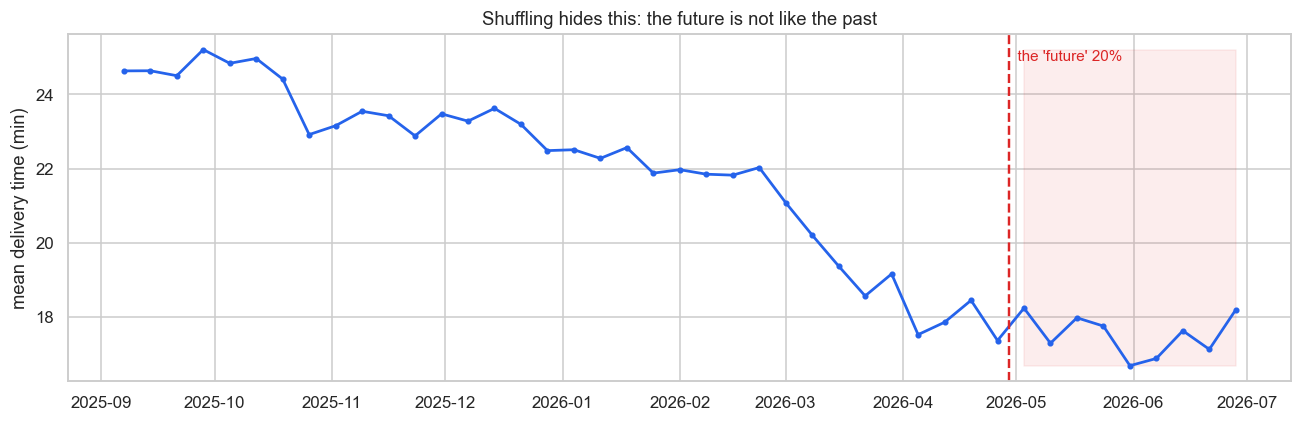

In [7]:
# Why the gap exists, in one picture: the thing we are predicting moved.
fig, ax = plt.subplots(figsize=(12, 4))
weekly = ordered.set_index("order_time")[TARGET].resample("W").mean()
ax.plot(weekly.index, weekly.values, color="#2563eb", lw=1.8, marker="o", ms=3)
ax.axvline(ordered.loc[cut, "order_time"], color="#dc2626", ls="--", lw=1.6)
ax.fill_between(weekly.index, weekly.min(), weekly.max(),
                where=weekly.index >= ordered.loc[cut, "order_time"],
                color="#dc2626", alpha=0.08)
ax.text(ordered.loc[cut, "order_time"], weekly.max(), "  the 'future' 20%",
        color="#dc2626", va="top", fontsize=10)
ax.set(ylabel="mean delivery time (min)",
       title="Shuffling hides this: the future is not like the past")
fig.tight_layout()

The red region is genuinely faster than the blue one. A shuffled fold gets to
learn that from rows *inside* the red region; a deployed model does not.

**The rule:** if your rows have a time order and you will deploy forward in
time, validate forward in time. Not because it is stricter for its own sake,
but because it is the only setup that matches how the model will be used.

Two things people get wrong right after learning this:

- **`TimeSeriesSplit` also trains on less data** than a random fold, so part of
  its worse score is just smaller training sets rather than honest difficulty.
  The train-on-past/score-on-future number is the one to quote.
- **A time split is not always right.** If your rows genuinely have no order —
  independent customers, a static population — shuffling is correct and a time
  split needlessly throws away data. Match the split to how the model gets used.

---

# Leak 4 — target encoding, the one that survives review

This is the worst of the four, and the reason is that the code looks careful.

`customer_id` has thousands of levels, so one-hot encoding is out. The standard
move for a high-cardinality key is **target encoding**: replace each category
with the average target for that category. Regular customers who live far away
get a high number, nearby ones get a low number, and the model gets a useful
summary in one column.

Here is the careful-looking version. The author even remembered to compute the
encoding on the training set only, so the test set is untouched.

Before we run it: what is wrong?

In [8]:
train_df, test_df = train_test_split(deliveries, test_size=0.2,
                                     random_state=RANDOM_STATE)

# Compute the encoding on the TRAINING data only. This feels safe. It is not.
encoding = train_df.groupby("customer_id")[TARGET].mean()
global_mean = train_df[TARGET].mean()

train_enc = train_df.assign(customer_mean=train_df["customer_id"].map(encoding))
test_enc = test_df.assign(
    customer_mean=test_df["customer_id"].map(encoding).fillna(global_mean))

WITH_TE = NUMERIC + ["customer_mean"]
pipe_te = make_pipeline_for(WITH_TE, CATEGORICAL)
cols_te = WITH_TE + CATEGORICAL

# Cross-validate inside the training set, exactly as you normally would.
cv_with = cv_mae(pipe_te, train_enc[cols_te], train_enc[TARGET])
cv_without = cv_mae(make_pipeline_for(NUMERIC, CATEGORICAL),
                    train_df[FEATURES], train_df[TARGET])

print(f"cross-validated MAE without customer_mean : {cv_without:.2f} min")
print(f"cross-validated MAE with    customer_mean : {cv_with:.2f} min")
print(f"                                    -> {(1 - cv_with / cv_without):+.0%}, "
      "our best feature yet")

cross-validated MAE without customer_mean : 4.94 min
cross-validated MAE with    customer_mean : 4.48 min
                                    -> +9%, our best feature yet


A clear improvement, cross-validated, with the encoding fitted on training data
only. This is the point at which it goes in the deck.

Now look at the held-out test set — which the encoding genuinely never touched.

In [9]:
# Now we spend the test set. This is the one look we get, and it is the only
# number in this notebook that the encoding could not possibly have seen.
fitted_te = pipe_te.fit(train_enc[cols_te], train_enc[TARGET])
holdout_te = mean_absolute_error(test_enc[TARGET], fitted_te.predict(test_enc[cols_te]))

fitted_plain = make_pipeline_for(NUMERIC, CATEGORICAL).fit(
    train_df[FEATURES], train_df[TARGET])
holdout_plain = mean_absolute_error(test_df[TARGET],
                                    fitted_plain.predict(test_df[FEATURES]))

comparison = pd.DataFrame([
    {"model": "without customer_mean", "CV": cv_without, "holdout": holdout_plain},
    {"model": "with customer_mean", "CV": cv_with, "holdout": holdout_te},
]).round(2)
print(comparison.to_string(index=False))
print(f"\nCV said the feature was worth {(1 - cv_with / cv_without):+.0%}")
print(f"the holdout says it is worth   {(1 - holdout_te / holdout_plain):+.0%}")

                model   CV  holdout
without customer_mean 4.94     4.74
   with customer_mean 4.48     5.52

CV said the feature was worth +9%
the holdout says it is worth   -16%


The feature that cross-validation called our best is, on data the encoding
never saw, **actively harmful.**

And now the part that should genuinely bother you:

> **`customer_id` has no effect on delivery time in this dataset. None. I
> generated the data; customers were assigned at random and never enter the
> formula for `delivery_minutes`.**

A column containing exactly zero information looked like the strongest feature
in the model.

## Why

Customers average about four orders each. When you compute
`mean(delivery_minutes)` for a customer with four orders and then use it as a
feature *for those same four rows*, roughly a quarter of the feature is the
row's own answer. The model finds it instantly.

Fitting the encoding "on the training set only" does not help, because the
cross-validation folds live *inside* the training set. Every fold's validation
rows contributed to the encoding that fold is scored with.

**The encoding has to be recomputed inside every fold, from that fold's
training rows only.** That is fiddly to write by hand — which is exactly why it
belongs inside the Pipeline, where sklearn does it for you.

In [10]:
from sklearn.preprocessing import TargetEncoder

# TargetEncoder does the cross-fitting internally: each row's encoding is
# computed from folds that exclude it, and it is refitted per CV fold because
# it sits inside the Pipeline.
pipe_safe = make_pipeline_for(
    NUMERIC, CATEGORICAL,
    extra_steps=[("te", TargetEncoder(random_state=RANDOM_STATE), ["customer_id"])],
)
cols_safe = FEATURES + ["customer_id"]

cv_safe = cv_mae(pipe_safe, train_df[cols_safe], train_df[TARGET])
holdout_safe = mean_absolute_error(
    test_df[TARGET],
    pipe_safe.fit(train_df[cols_safe], train_df[TARGET]).predict(test_df[cols_safe]))

final = pd.DataFrame([
    {"approach": "no customer feature", "CV": cv_without, "holdout": holdout_plain},
    {"approach": "naive target encoding", "CV": cv_with, "holdout": holdout_te},
    {"approach": "TargetEncoder in the pipeline", "CV": cv_safe, "holdout": holdout_safe},
]).round(2)
print(final.to_string(index=False))

                     approach   CV  holdout
          no customer feature 4.94     4.74
        naive target encoding 4.48     5.52
TargetEncoder in the pipeline 4.94     4.73


Done properly, the CV score and the holdout score agree, and both say what is
actually true: **this column is worth nothing.**

That is the result you want. Not a better number — an honest one. A method
that correctly tells you a feature is useless has just saved you from shipping
it.

### When target encoding is genuinely the right tool

It is not a trap in itself, only when hand-rolled:

- **Do** use it for high-cardinality keys where one-hot is impractical:
  postcode, product id, merchant.
- **Do** put it inside the pipeline, always.
- **Watch out** for categories with very few rows. `TargetEncoder` smooths
  towards the global mean, which is what stops rare categories from being pure
  noise — but if most of your categories have three rows, ask whether the
  column belongs in the model at all.
- **Remember the group question too.** If the same customer appears in train
  and validation, you may also want `GroupKFold` on top. The two problems are
  independent and you can have both at once.

---

## Metrics: what each one hides

We have used MAE throughout because it is in minutes and needs no translation.
That was a choice. Before the case study, it is worth seeing the alternatives —
because over there the metric changes which model wins.

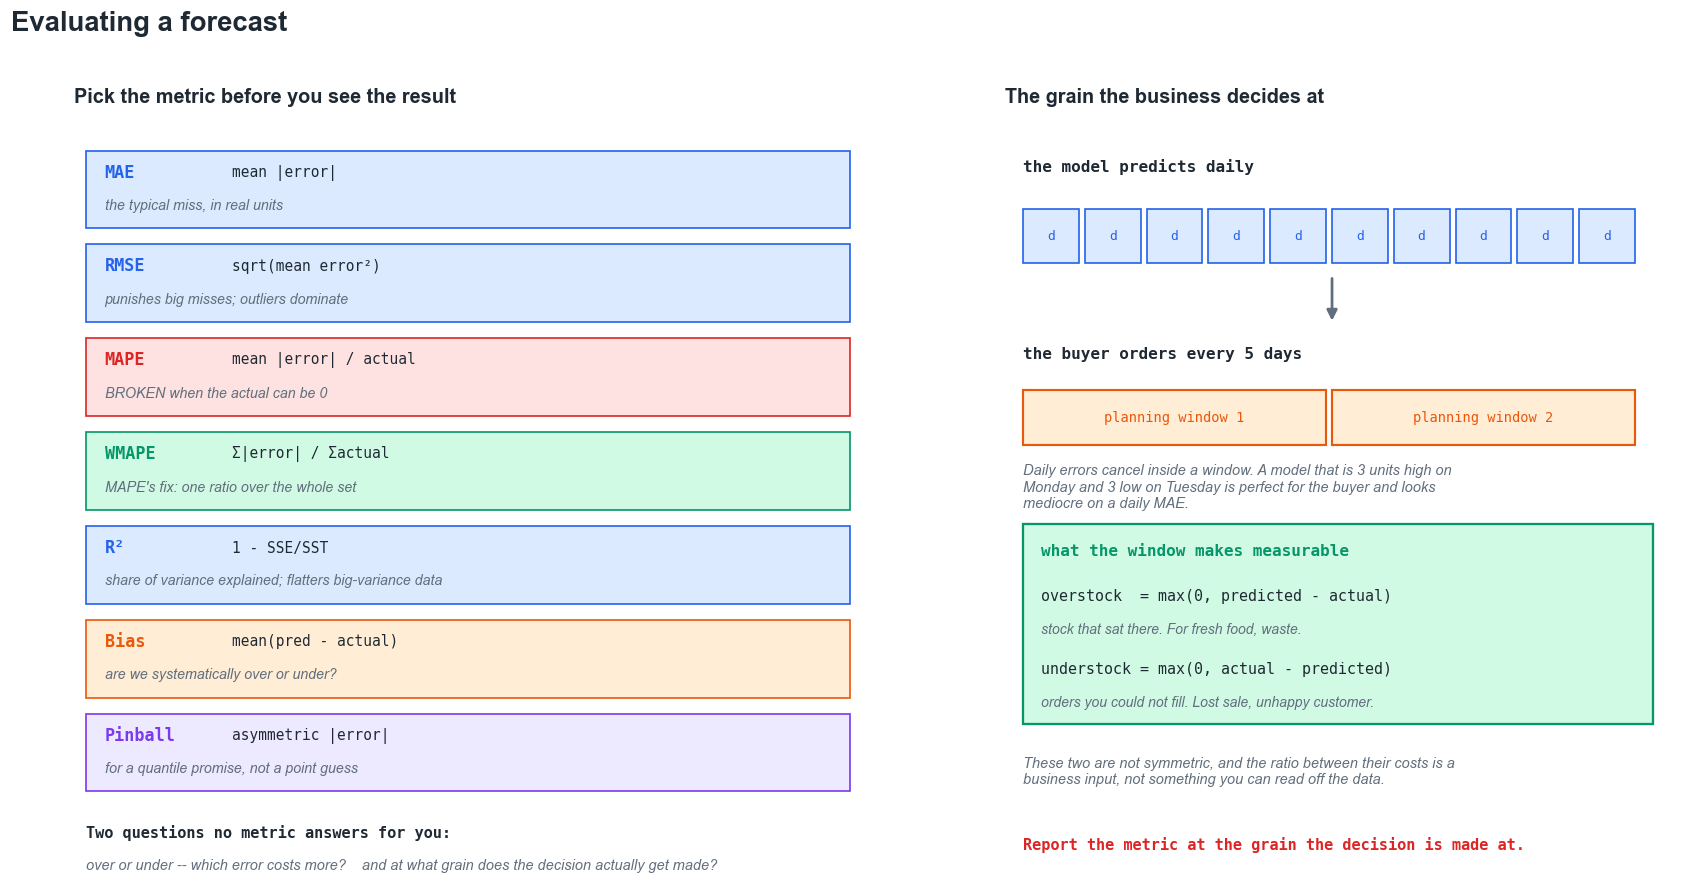

In [11]:
metrics_sheet();   # also assets/metrics_sheet.png

The right-hand panel is the one people skip and then regret. **The grain you
evaluate at can reverse the ranking of your models.** Notebook 07 has a case
where the dumbest model on the list turns out to be the best one, once it is
scored the way the business actually consumes the forecast.

Two questions no metric answers for you, and both need a person:

- **Which error costs more, over or under?** Overstocking fresh food is waste;
  understocking is a lost sale and an annoyed customer. They are rarely equal
  and the ratio is a business input.
- **At what grain is the decision made?** If the buyer orders every five days,
  a daily metric is measuring something nobody acts on.

---

# Which split, then?

Four leaks, three of which were really the same question wearing different
clothes: **what does my validation fold have to look like for the score to mean
what I think it means?**

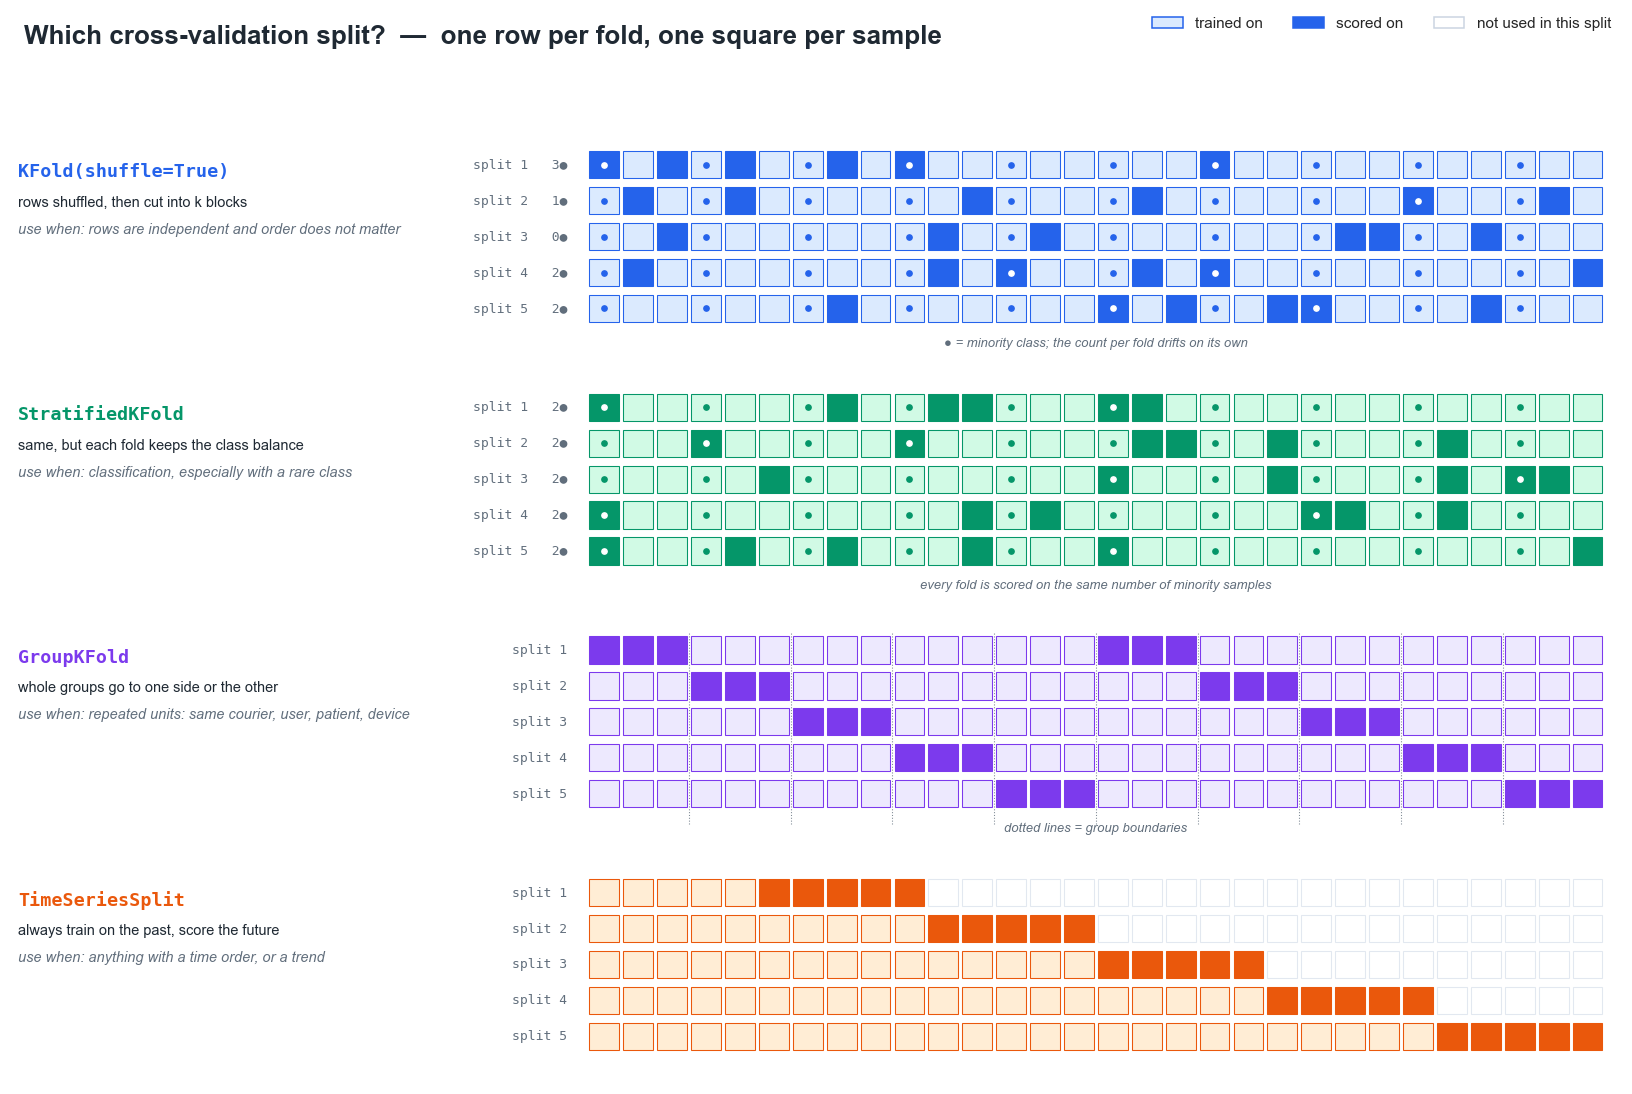

In [12]:
cv_schemes();   # also assets/cv_schemes.png

Look at split 3 in the top block: that fold contains **zero** minority-class
samples. Score recall on it and you get a division by zero or a meaningless
number. That is what stratification is for.

The decision procedure, in order:

1. **Do my rows have a time order and will I deploy forward?** → `TimeSeriesSplit`,
   or a plain train-on-past / score-on-future split.
2. **Does one real entity produce many rows?** → `GroupKFold` on that entity.
3. **Is it classification with an imbalanced target?** → `StratifiedKFold`.
4. **None of the above?** → `KFold(shuffle=True)`.

You can need more than one. `StratifiedGroupKFold` exists for exactly that, and
for time plus groups you generally have to write the split yourself.

---

# Feature engineering, without cheating

Now that we know how to measure honestly, we can actually try to improve the
model. Every feature below is built **inside** the pipeline, or from columns
in the same row — never from an aggregate over the whole dataset.

The rule that keeps you safe: *if computing a feature requires looking at rows
other than this one, it has to happen inside the fold.*

In [13]:
from sklearn.preprocessing import FunctionTransformer

def add_ratios(X):
    """Row-wise features only -- nothing here looks at another row.

    That is what makes this safe to compute outside the fold: there is no
    quantity being estimated from the data, so there is nothing to leak.
    """
    X = X.copy()
    # Value per item: separates "a big weekly shop" from "one expensive thing".
    X["value_per_item"] = X["basket_value_toman"] / X["basket_size"]
    # The store's own estimate, per kilometre -- a crude congestion signal.
    X["prep_per_km"] = X["prep_minutes"] / X["distance_km"].clip(lower=0.3)
    # Cyclical hour: 23:00 and 00:00 are one hour apart, not 23.
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
    return X


ENGINEERED = NUMERIC + ["value_per_item", "prep_per_km", "hour_sin", "hour_cos"]

pipe_fe = Pipeline([
    ("ratios", FunctionTransformer(add_ratios)),
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), ENGINEERED),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]), CATEGORICAL),
    ])),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])

cv_fe = cv_mae(pipe_fe, train_df[FEATURES], train_df[TARGET])
print(f"before feature engineering: {cv_without:.2f} min")
print(f"after  feature engineering: {cv_fe:.2f} min   ({(1 - cv_fe/cv_without):+.1%})")

before feature engineering: 4.94 min
after  feature engineering: 4.96 min   (-0.4%)


Nothing. Four sensible-looking features and the score did not move — if
anything it is a hair worse, which is what noise looks like.

I am showing you this result rather than hunting for one that works, because
it is the usual result and nobody puts it in a tutorial. Gradient boosting
already finds ratios and interactions on its own; that is most of what the
trees are doing. Hand-built features pay off far more with **linear** models,
or when they encode something the model genuinely cannot derive from the
columns it has: a distance from a real routing API, a public-holiday calendar,
weather from another table.

The useful move here is not to keep adding transformations of the same eight
columns. It is to go and find a ninth.

**The honest ordering of effort on tabular problems:**

1. Fix the validation. (largest effect, and everything else is unmeasurable without it)
2. Get more or better *rows*.
3. Bring in genuinely new information from outside the table.
4. Feature engineering on the columns you already have.
5. Hyperparameter tuning.

Most people spend their time in reverse order.

---

# Error analysis: what is it bad at?

A single MAE tells you nothing about *where* the model fails, and "where"
is what you take to the next meeting.

                   mae  bias    n
delivery_minutes                 
(0, 15]           4.91  4.49  561
(15, 20]          3.65  1.49  568
(20, 25]          3.61  0.15  528
(25, 32]          4.51 -3.22  494
(32, 200]         9.73 -9.59  249


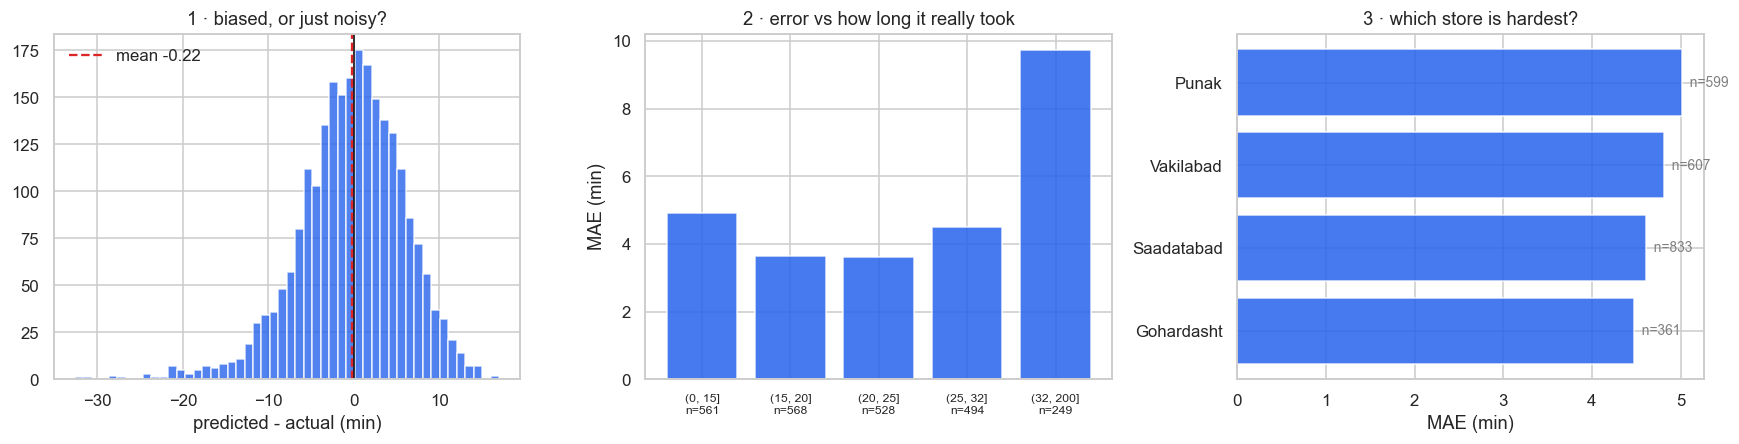

In [14]:
predicted = fitted_plain.predict(test_df[FEATURES])
errors = test_df.assign(
    predicted=predicted,
    error=predicted - test_df[TARGET],          # signed: negative = under-promised
    abs_error=np.abs(predicted - test_df[TARGET]),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1. Are the errors centred, or is the model biased?
axes[0].hist(errors["error"], bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(errors["error"].mean(), color="#dc2626", ls="--",
                label=f"mean {errors['error'].mean():+.2f}")
axes[0].set(xlabel="predicted - actual (min)", title="1 · biased, or just noisy?")
axes[0].legend(frameon=False)

# 2. Does the error depend on the size of the answer? Almost always yes.
bins = pd.cut(errors[TARGET], [0, 15, 20, 25, 32, 200])
by_size = errors.groupby(bins, observed=True).agg(
    mae=("abs_error", "mean"), bias=("error", "mean"), n=("error", "size"))
axes[1].bar(range(len(by_size)), by_size["mae"], color="#2563eb", alpha=0.85)
axes[1].set(xticks=range(len(by_size)), ylabel="MAE (min)",
            title="2 · error vs how long it really took")
axes[1].set_xticklabels([f"{i}\nn={n}" for i, n in zip(by_size.index, by_size["n"])],
                        fontsize=8)

# 3. Which segments are worst? Sorted, because unsorted bars hide the answer.
by_store = (errors.groupby("store")
            .agg(mae=("abs_error", "mean"), n=("abs_error", "size"))
            .sort_values("mae"))
axes[2].barh(by_store.index, by_store["mae"], color="#2563eb", alpha=0.85)
axes[2].set(xlabel="MAE (min)", title="3 · which store is hardest?")
for i, (m, n) in enumerate(zip(by_store["mae"], by_store["n"])):
    axes[2].text(m, i, f"  n={n}", va="center", fontsize=9, color="grey")

fig.tight_layout()
print(by_size.round(2).to_string())

The middle panel is the one that always says the same thing, and it is worth
internalising: **the model is good at ordinary deliveries and bad at slow
ones.** Error grows with the size of the answer.

That is not a bug you can tune away — it is the shape of the problem. Slow
deliveries are slow because something unpredictable happened. What it means in
practice is that the promise on the screen should not be a point estimate. It
should be a quantile, with the uncertainty built in. Which brings us back to
the metric choice on the first page of notebook 04.

Now the other half of error analysis, and the half people skip: **read the
actual rows.**

In [15]:
# Aggregates tell you the size of the problem; individual rows tell you what
# it is. Always read some.
worst = errors.nlargest(10, "abs_error")[
    ["order_time", "store", "courier_type", "weather", "distance_km",
     "basket_size", TARGET, "predicted", "error"]]
print("the ten worst predictions:")
print(worst.round(1).to_string(index=False))

# If a tiny fraction of rows carries a large share of the total error, the
# ceiling on this model is set by those rows, not by the average one.
print("\nhow much of the total error comes from the worst 1% of orders?")
share = errors.nlargest(int(len(errors) * 0.01), "abs_error")["abs_error"].sum()
print(f"  {share / errors['abs_error'].sum():.0%}")

the ten worst predictions:
         order_time      store courier_type weather  distance_km  basket_size  delivery_minutes  predicted  error
2026-01-29 20:25:00      Punak   motorcycle    rain          5.3            4              65.3       32.7  -32.6
2025-12-12 18:52:00  Vakilabad      bicycle    rain          3.9            4              63.8       32.2  -31.6
2025-12-13 12:44:00  Vakilabad      bicycle   clear          2.5            3              49.4       21.3  -28.1
2025-09-14 20:34:00      Punak      bicycle   clear          3.3            3              54.7       27.0  -27.7
2025-09-23 21:47:00 Saadatabad      bicycle   clear          3.3            5              52.6       25.5  -27.1
2026-01-09 19:21:00      Punak   motorcycle   clear          3.0            6              48.1       23.8  -24.3
2025-09-18 13:10:00  Vakilabad      bicycle   clear          4.7            4              57.9       33.7  -24.2
2025-10-04 22:32:00 Saadatabad   motorcycle   clear          

Reading ten rows is worth more than any aggregate. You are looking for a
pattern you can name: are they all the same store? all in the rain? all long
distances? all at 22:00?

Here they are mostly the incidents — the deliveries where something went wrong
that nothing in the input could have predicted. That is a real finding and it
has a real consequence: **more feature engineering will not fix these.** If you
want to improve on this, you need a new signal from outside the table — live
traffic, whether the courier already had another order, whether the building
has a lift.

Saying "here is the ceiling and here is what would move it" is a far better
result than another 0.1 minutes of tuning.

---

# The checklist

Print this. Stick it next to the EDA checklist from week 2.

**Before you model**
- [ ] What decision does this change? What is the metric, and why that one?
- [ ] Split **first**. Nothing computed before the split.
- [ ] A stupid baseline, written down, before anything clever.

**Every column, one at a time**
- [ ] Was this value known at prediction time? Ask the engineer who owns the
      table *when it is written*, not what it means.
- [ ] Does it improve the score? — **not a test for legality.**

**The split**
- [ ] Time order + deployed forward → split forward in time.
- [ ] One entity, many rows → `GroupKFold` on that entity.
- [ ] Imbalanced classification → `StratifiedKFold`.
- [ ] Needs two of the above → say so out loud; do not quietly pick one.

**Preprocessing**
- [ ] Everything learned from data lives **inside** the `Pipeline`.
- [ ] `handle_unknown="ignore"` on every encoder.
- [ ] Target encoding: inside the pipeline, never hand-rolled.

**Reporting**
- [ ] Quote the fold-to-fold spread, not just the mean.
- [ ] Compare against the baseline, in the unit the business uses.
- [ ] Say what the model is bad at before you are asked.
- [ ] If CV and the holdout disagree, the holdout is right and you have a leak.

---

# Exercises

**1 — Find the leak.** In `data/deliveries.csv` there is one more column
combination that leaks, which we did not cover. Find it, measure it, and say
which of the four categories it belongs to.

**2 — The right split.** Suppose the fleet has 30% courier turnover per month.
Which validation scheme should this project use, and what would you report to a
manager who asks "how accurate is it"? Write three sentences, not code.

**3 — A promise, not a guess.** Refit the pipeline with
`HistGradientBoostingRegressor(loss="quantile", quantile=0.9)` and compare the
predictions to the MAE model. How often is each one late? Which would you put
on the customer's screen?

Solutions go up after the session in `05_exercises_solutions.ipynb`.

---

# Next week

Week 4 leaves tabular data for neural networks. Two things carry over
unchanged: **split before you touch anything**, and **the metric is a business
decision**. The failure modes get new names, but they are the same failure
modes.